# 01 — Backtest : « suivre le Congrès » bat-il le marché *net de coûts* ?

> Book de recherche **isolé** (`00. S3S4 en cours/`). On **lit** les données du dépôt, on n'écrit que
> dans ce dossier. Le moteur (`data.py`, `prices.py`, `portfolio.py`, `evaluate.py`, `variants.py`,
> `leadership.py`) est importé ; ce notebook en **documente le raisonnement** : pour chaque variante, le code, le
> résultat, puis le verdict.

**Question** : une stratégie de copy-trading des achats du Congrès dégage-t-elle un **alpha net** (après
coûts et ajustement factoriel) sur l'historique long **Quiver 2014-2026** ?

**Les 4 facteurs qui peuvent annuler l'edge, traités d'emblée** : (1) coûts & turnover (20 bps/côté) ; (2) entrée stricte à
la **date de divulgation** `filed` + 1 jour (pas de look-ahead) ; (3) **ajustement Fama-French-Carhart**
(isoler le beta tech) + **Deflated Sharpe** ; (4) **OOS** (Sharpe in-sample → out-of-sample).
*Limite assumée* : l'univers prix exclut les tickers délistés ⇒ **survivorship** (verdict = borne haute).

In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = os.path.join(base, '00. S3S4 en cours')
    if os.path.exists(os.path.join(p, 'data.py')): S3 = p; break
sys.path.insert(0, S3)
import numpy as np, pandas as pd
import data, prices, portfolio, evaluate, variants as V, leadership as LEAD
%matplotlib inline
import matplotlib.pyplot as plt
print('moteur importé depuis :', S3)

moteur importé depuis : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


## 1. Les données — journal des transactions Quiver (2014-2026)
`data.load_transactions()` charge les deux caches Quiver (House + Sénat), normalise, et renvoie le journal.
`buy_signals()` ne garde que les **achats tickés** (= signaux d'entrée long).

In [2]:
df = data.load_transactions()
buys = data.buy_signals(df)
print(f"{len(df):,} transactions | {len(buys):,} achats tickés | "
      f"{buys['bioguide'].nunique()} membres | {buys['ticker'].nunique()} tickers | "
      f"filed {df['filed'].min().date()} -> {df['filed'].max().date()}".replace(',', ' '))
buys.head(3)

113 675 transactions | 56 877 achats tickés | 251 membres | 3797 tickers | filed 2014-01-03 -> 2026-06-23


,chamber,bioguide,name,ticker,op,traded,filed,size_usd,party
0,house,T000490,David J. Taylor,T,buy,2026-06-05,2026-06-12,1001.0,Republican
1,house,T000490,David J. Taylor,GOOGL,buy,2026-06-05,2026-06-12,1001.0,Republican
2,house,T000490,David J. Taylor,KR,buy,2026-06-05,2026-06-12,1001.0,Republican


## 2. Les prix (cache local) + benchmark + facteurs
`prices.load_panel()` lit les cours ajustés **déjà en cache** ; `get_spy()` le benchmark ; `get_factors()`
les facteurs Fama-French-Carhart. **Couverture** = part des achats dont le ticker a un prix.

In [3]:
panel = prices.load_panel(list(buys['ticker'].value_counts().index))
spy = prices.get_spy(); factors = prices.get_factors()
cov = buys['ticker'].isin(panel.columns).mean()
print(f"{panel.shape[1]} tickers en cache | couvre {cov*100:.0f}% des achats | "
      f"{panel.index.min().date()} -> {panel.index.max().date()} | facteurs: {list(factors.columns)}")

2171 tickers en cache | couvre 83% des achats | 2013-06-03 -> 2026-06-25 | facteurs: ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']


## 3. Du signal aux positions, puis aux 9 variantes
**Règle** : chaque achat ouvre une position à `filed`+1 jour de bourse ; sortie = vente correspondante du
même membre+ticker, sinon après un horizon H. Portefeuille rebalancé quotidiennement, **net de coûts**.

On teste un **éventail de constructions** (du naïf au ciblé) dans le *même* évaluateur — c'est la couche de validation : `evaluate.factor_alpha` (alpha FF-Carhart + t), `deflated_sharpe`, `oos_split`.

In [4]:
COST_BPS = 20.0
VARIANTS = [
    {'label': 'V0 equal 12m',      'w': 'equal',     'h': 12},
    {'label': 'equal 6m',          'w': 'equal',     'h': 6},
    {'label': 'size brut 6m',      'w': 'size',      'h': 6},
    {'label': 'sqrt-size 6m',      'w': 'sqrt_size', 'h': 6},
    {'label': 'deconcentre 6m',    'w': 'equal',     'h': 6, 'dampen': True},
    {'label': 'conviction>=2 6m',  'w': 'equal',     'h': 6, 'conv': True},
    {'label': 'leadership PIT 6m', 'w': 'equal',     'h': 6, 'leader': 'pit'},
    {'label': 'chairs 6m',         'w': 'equal',     'h': 6, 'leader': 'chairs'},
    {'label': 'leaders+chairs 6m', 'w': 'equal',     'h': 6, 'leader': 'any'},
]
pos_cache, rows, nets, conv_mask, lead_masks = {}, [], {}, None, {}
for v in VARIANTS:
    label, w, h = v['label'], v['w'], v['h']; leader = v.get('leader')
    key = (h, v.get('conv', False), leader)
    if key not in pos_cache:
        b = buys
        if v.get('conv'):
            if conv_mask is None: conv_mask = V.conviction_mask(buys)
            b = buys[conv_mask.values]
        elif leader:
            if leader not in lead_masks: lead_masks[leader] = LEAD.leadership_mask(buys, leader)
            b = buys[lead_masks[leader].values]
        pos_cache[key] = portfolio.build_positions(b, df, horizon_months=h)
    pos = pos_cache[key]
    if v.get('dampen'):
        pos = pos.copy(); pos['raw'] = V.member_dampen_raw(pos)
    r = portfolio.run_portfolio(pos, panel, weighting=w, cost_bps=COST_BPS)
    g, net = portfolio.perf_vs_spy(r['gross'], spy), portfolio.perf_vs_spy(r['net'], spy)
    fa, oos = evaluate.factor_alpha(r['net'], factors), evaluate.oos_split(r['net'])
    nets[label] = r['net']
    rows.append({'variante': label, 'CAGR_brut_%': round(g['CAGR']*100, 2), 'CAGR_net_%': round(net['CAGR']*100, 2),
                 'SPY_%': round(net['CAGR_SPY']*100, 2), 'alpha_fact_%': round(fa['alpha_annuel']*100, 2),
                 't_alpha': round(fa['alpha_t'], 2), 'beta_mkt': fa['beta_marche'],
                 'maxDD_%': round(net['max_drawdown']*100, 1), 'IS->OOS': f"{oos['sharpe_IS']}->{oos['sharpe_OOS']}"})
sr = [evaluate._sr_stats(nets[x['variante']])[0] for x in rows]
sr_std = float(np.std(sr, ddof=1))
for x in rows: x['DSR'] = round(evaluate.deflated_sharpe(nets[x['variante']], sr_std, len(rows)), 2)
res = pd.DataFrame(rows).set_index('variante')
res

,CAGR_brut_%,CAGR_net_%,SPY_%,alpha_fact_%,t_alpha,beta_mkt,maxDD_%,IS->OOS,DSR
variante,,,,,,,,,
V0 equal 12m,26.93,25.45,13.70,10.84,2.03,0.913,-35.6,1.17->0.8,1.00
equal 6m,32.75,30.41,13.70,15.18,1.99,0.902,-35.7,1.14->0.82,1.00
size brut 6m,10.18,9.33,13.70,6.67,1.16,0.125,-14.8,0.68->0.0,0.98
sqrt-size 6m,15.55,14.72,13.70,11.84,1.64,0.135,-14.3,0.86->0.0,1.00
deconcentre 6m,27.53,25.53,13.70,12.11,1.72,0.895,-34.5,1.05->0.72,1.00
conviction>=2 6m,14.11,12.22,13.68,-1.02,-0.98,0.943,-35.2,0.74->0.71,0.95
leadership PIT 6m,14.59,13.09,13.97,0.99,0.25,0.909,-41.1,0.64->0.67,0.91
chairs 6m,13.35,11.51,14.03,-1.04,-0.69,0.906,-39.0,0.6->0.83,0.93
leaders+chairs 6m,12.74,10.87,13.97,-1.61,-1.10,0.905,-37.9,0.57->0.81,0.92


## 4. Courbe de capital (net de coûts) vs SPY

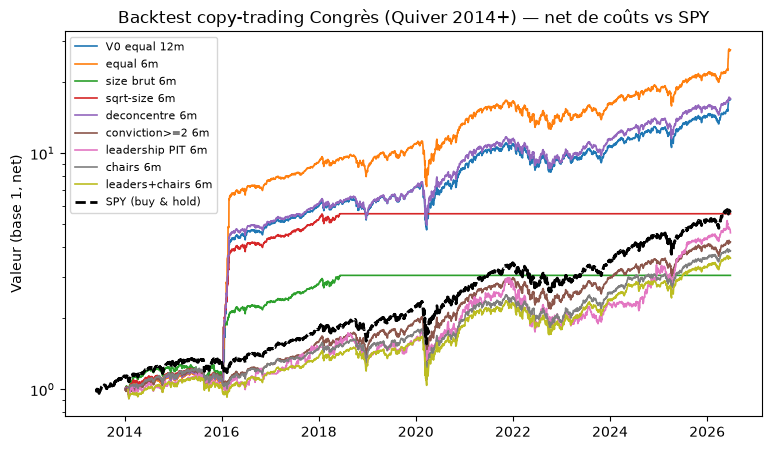

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, s in nets.items():
    a = s[s != 0]
    if len(a): ax.plot((1 + s.loc[a.index[0]:]).cumprod(), lw=1.2, label=label)
spr = spy.pct_change().reindex(list(nets.values())[0].index).fillna(0)
ax.plot((1 + spr).cumprod(), 'k--', lw=2, label='SPY (buy & hold)')
ax.set_yscale('log'); ax.set_ylabel('Valeur (base 1, net)'); ax.legend(fontsize=8)
ax.set_title('Backtest copy-trading Congrès (Quiver 2014+) — net de coûts vs SPY'); plt.show()

## 5. Verdict du backtest

Lecture de la colonne **`t_alpha`** (l'alpha Fama-French-Carhart, net) :

- **Aucune des 9 variantes** ne dégage d'alpha factoriel **significatif** (tous `|t| < 1,2`).
- L'**equal-weight** ≈ le marché (β ≈ 0,9) et perd légèrement net après coûts ; le **size brut / sqrt-size**
  s'effondrent (concentration sur quelques méga-trades, Sharpe **OOS → 0**).
- **conviction-cluster** et **dé-concentration** n'aident pas. Le **leadership de parti** semble positif
  (+α) **mais** ~80 % de l'échantillon vient d'**un seul membre** (Lisa McClain) et `t≈0,6` ⇒ effet imputable à un seul membre. Les **chairs** ne montrent rien.
- Et c'est un **plancher optimiste** (tickers délistés exclus → survivorship haussier).

➡️ **Pas d'edge net exploitable** par une stratégie « suivre le Congrès » sur 2014-2026. La *où* il
pourrait rester un peu d'information est exploré dans **`SUPP_B_chasse_au_signal.ipynb`**.